# Generative Adversarial Networks (GAN) Implementation on MNIST Dataset

## Overview

We implement a simple **Generative Adversarial Network (GAN)** using PyTorch to generate synthetic handwritten digits based on the MNIST dataset.

A GAN consists of two neural networks:

*   **Generator**: Learns to produce realistic images from random noise.
*   **Discriminator**: Learns to distinguish between real and generated images.

The networks are trained in a competitive setting where the Generator aims to fool the Discriminator, while the Discriminator tries to correctly classify real vs. generated images.

## Dataset

We use the **MNIST** dataset, which consists of 70,000 images of grayscale handwritten digits (0-9) of size **28x28** pixels. 
The images are normalized to the range $[-1,1]$ for stable GAN training.

## Model Architecture

### Generator

The Generator takes a random noise vector of size `latent_dim=100` as input and outputs a $28 \times 28$ image. 
It uses a series of **transposed convolution layers** (`ConvTranspose2d`) to upsample the noise into an image. 
The network architecture includes:

- A **`ConvTranspose2d`** layer that transforms the noise (shape `(100, 1, 1)`) into a $512 \times 4 \times 4$ tensor.
- **Batch normalization** (`BatchNorm2d`) and **ReLU activations** are used after each transpose convolution layer to stabilize training and introduce non-linearity.
- Three similar combinations of (`ConvTranspose2d`, `BatchNorm2d`, `ReLU`) follows.
- A final **`Conv2d`** layer reduces the tensor to the target size of $1 \times 28 \times 28$ (a grayscale image) with a **Tanh activation** to produce pixel values in the range $[-1, 1]$.

### Discriminator

The discriminator is a **binary** classifier that takes an image as input and outputs a probability score indicating whether the image is real or generated. It consists of **convolutional layers** (`Conv2d`) that progressively reduce the spatial dimensions of the image while extracting features:

- The first convolution layer reduces the input image from $28 \times 28$ to $14 \times 14$ with **`LeakyReLU`** activations and **Dropout** for regularization.
- The second convolution layer reduces the image size further to $7 \times 7$, with **`BatchNorm2d`**, **`LeakyReLU`** activations, and **Dropout**.
- The final convolutional layer further reduces the image to a $4 \times 4$ spatial size, followed by **`BatchNorm2d`**, **`LeakyReLU`** activations, and **Dropout**.
- The output is flattened and passed through a **linear layer** to produce a single scalar output, which can be interpreted as the probability that the image is real (without the final sigmoid, as this would typically be done during the loss computation).


<span style="font-size:smaller">
Note: When building the GAN networks, we refer to the structure introduced 
<a href="https://medium.com/@simple.schwarz/how-to-build-a-gan-for-generating-mnist-digits-in-pytorch-b9bf71269da8">here</a>.
</span>


#### 1. Necessary Packages

Import libraries for neural networks, data handling, and plotting.

Utilizes GPU if available for faster training.

In [ ]:
!pip install torchinfo

In [2]:
import torch
import torchvision
from torch.utils.data import DataLoader
from torchinfo import summary
import matplotlib.pyplot as plt
import math
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

#### 2. Data Preparation

Load the MNIST dataset using `torchvision.datasets.MNIST` and instantiate `train_loader` and `test_loader` via `DataLoader`, which handles batching and shuffling.

Note:

1. `torchvision.transforms.Compose`: Composes several transforms together.

2. `torchvision.transforms.Normalize(mean, std, inplace=False)`:
$$\frac{\text{input} - \text{mean}}{\text{std}}$$
Normalize grayscale images, which are in range [0,1] after `ToTensor`, to the range [-1,1], required for Tanh activation in the Generator. 
It takes `tensor` as input only.

3. Images in MNIST are not shuffled by default, so we set `shuffle=True` for test set to visualize the generated images for different digits easily.


In [3]:
batch_size = 256

# transform images to tensor in range [-1,1]
transform = torchvision.transforms.Compose([
    torchvision.transforms.ToTensor(),
    torchvision.transforms.Normalize((0.5,), (0.5,))
])

# Load training and test datasets and their according data loaders
train_dataset = torchvision.datasets.MNIST(root="./data", train=True, transform=transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

test_dataset = torchvision.datasets.MNIST(root="./data", train=False, transform=transform, download=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=True)

#### 3. Image Visualization

Define the function to display multiple images, and if labels are given, also append them to the bottom of the corresponding images.

By default, this function will display 10 images per row.

In [4]:
def show_images(images, labels=None, n_cols=10):
    """
    Display a grid of MNIST images (real or generated).

    Args:
        images (Tensor): Tensor of shape (B, 1, 28, 28) representing grayscale images.
        labels (Tensor or list, optional): Labels to display with the images.
        n_cols (int): Number of columns in the image grid.

    Returns:
        None. Displays a matplotlib grid of images.
    """
    # convert images into size B x 28 x 28, independent of their previous shape
    images = images.view(-1, 28, 28).cpu().detach().numpy()
    # convert back to [0,255] range
    images = torch.tensor((images + 1) * 127.5, dtype=torch.uint8)
    n_images = images.shape[0]
    n_rows = math.ceil(n_images / n_cols)

    # generate a figure with the given number of rows and columns
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols, n_rows * 1.2), squeeze=False)
    axes = axes.flatten()

    # iterate over all axes
    for i, ax in enumerate(axes):
        if i < n_images:
            ax.imshow(images[i], cmap='gray')
            ax.axis('off')

            # print label underneath the text
            if labels is not None and i < len(labels):
                # Convert label to string
                label = str(labels[i].item())
                y_offset = -0.1
                ax.text(0.5, y_offset, label, ha='center', va='center', transform=ax.transAxes, fontsize=12)

    plt.tight_layout()
    plt.show()

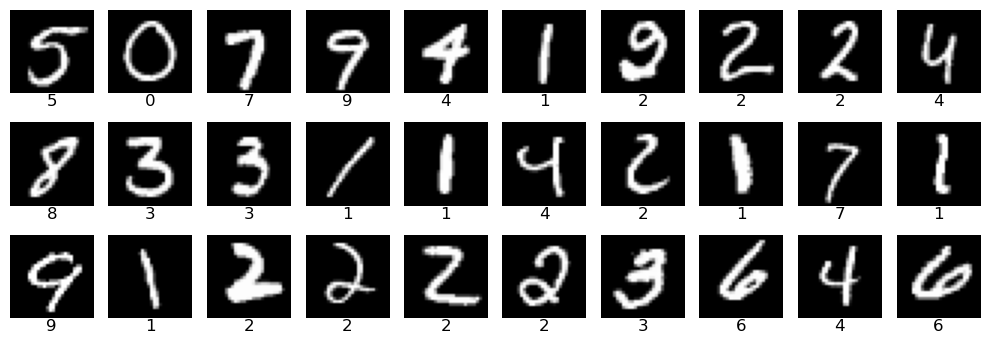

In [5]:
# display the first 30 images in a batch of the training set
one_train_batch, labels = next(iter(train_loader))
show_images(one_train_batch[:30],labels[:30])

#### 4. Define Generator

We define a Generator network to generate MNIST-style digit images from a latent noise vector using transposed convolution layers.
Since the network is a strict feed forward network, we rely on `torch.nn.Sequential` to define the Generator model in PyTorch.


Before building the network, some important layers:

--- 

**Transposed Convolution Layer**

```python
torch.nn.ConvTranspose2d(in_channels, out_channels, kernel_size, stride, padding, output_padding, bias=False)
```
A transposed convolution layer (also known as deconvolution) is used to upsample feature maps. [Documentation](https://pytorch.org/docs/stable/generated/torch.nn.ConvTranspose2d.html)

**Batch Normalization Layer**

```python
torch.nn.BatchNorm2d(num_features, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True, device=None, dtype=None)
```
[Documentation](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html)


In [3]:
def Generator():
    """
    Generator model for MNIST digit generation using ConvTranspose2d layers.

    Input: Noise vector of shape (B, 100, 1, 1)
    Output: Generated image of shape (B, 1, 28, 28)
    """
    return torch.nn.Sequential(

        torch.nn.ConvTranspose2d(in_channels=100, out_channels=512, kernel_size=4, stride=1, padding=0, bias=False),
        torch.nn.BatchNorm2d(512),
        torch.nn.ReLU(True),

        torch.nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=3, stride=2, padding=1, bias=False),
        torch.nn.BatchNorm2d(256),
        torch.nn.ReLU(True),

        torch.nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=4, stride=2, padding=1, bias=False),
        torch.nn.BatchNorm2d(128),
        torch.nn.ReLU(True),

        torch.nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=4, stride=2, padding=1, bias=False),
        torch.nn.BatchNorm2d(64),
        torch.nn.ReLU(True),

        torch.nn.Conv2d(in_channels=64, out_channels=1, kernel_size=3, stride=1, padding=1, bias=False),
        torch.nn.Tanh() # pixel ranges [-1, 1]
    )

In [4]:
net_G = Generator()
# Summary of the model including forward pass
summary(
    net_G, 
    input_data=torch.randn(1, 100, 1, 1), 
    device="cpu"
)

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1, 28, 28]            --
├─ConvTranspose2d: 1-1                   [1, 512, 4, 4]            819,200
├─BatchNorm2d: 1-2                       [1, 512, 4, 4]            1,024
├─ReLU: 1-3                              [1, 512, 4, 4]            --
├─ConvTranspose2d: 1-4                   [1, 256, 7, 7]            1,179,648
├─BatchNorm2d: 1-5                       [1, 256, 7, 7]            512
├─ReLU: 1-6                              [1, 256, 7, 7]            --
├─ConvTranspose2d: 1-7                   [1, 128, 14, 14]          524,288
├─BatchNorm2d: 1-8                       [1, 128, 14, 14]          256
├─ReLU: 1-9                              [1, 128, 14, 14]          --
├─ConvTranspose2d: 1-10                  [1, 64, 28, 28]           131,072
├─BatchNorm2d: 1-11                      [1, 64, 28, 28]           128
├─ReLU: 1-12                             [1, 64, 28, 28] 

#### 5. Define Discriminator

We define a convolutional neural network that takes in an MNIST image and outputs a score indicating whether the image is real or generated.
As common, the Discriminator is more lightweight than the Generator network.
Similarly as above, we just use `torch.nn.Sequential` to define our Discriminator network.

In [6]:
def Discriminator():
    """
    Discriminator model for classifying real vs generated MNIST images using Conv2d layers.

    Input: Image of shape (B, 1, 28, 28)
    Output: Real/generated prediction of shape (B, 1)
    """
    return torch.nn.Sequential(
        torch.nn.Conv2d(in_channels=1, out_channels=64, kernel_size=4, stride=2, padding=1),
        torch.nn.LeakyReLU(0.2),
        torch.nn.Dropout(0.5),

        torch.nn.Conv2d(in_channels=64, out_channels=128, kernel_size=4, stride=2, padding=1),
        torch.nn.BatchNorm2d(128),
        torch.nn.LeakyReLU(0.2),
        torch.nn.Dropout(0.5),

        torch.nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, stride=2, padding=1),
        torch.nn.BatchNorm2d(256),
        torch.nn.LeakyReLU(0.2),
        torch.nn.Dropout(0.5),

        torch.nn.Flatten(),  # Flatten before final linear layer
        torch.nn.Linear(256 * 4 * 4, 1),
        # torch.nn.Sigmoid()  # BCEWithLogitsLoss() will apply sigmoid automatically
    )

In [7]:
net_D = Discriminator()
# Summary of the model including forward pass
summary(
    net_D, 
    input_data=torch.randn(1, 1, 28, 28), 
    device="cpu"
)

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Conv2d: 1-1                            [1, 64, 14, 14]           1,088
├─LeakyReLU: 1-2                         [1, 64, 14, 14]           --
├─Dropout: 1-3                           [1, 64, 14, 14]           --
├─Conv2d: 1-4                            [1, 128, 7, 7]            131,200
├─BatchNorm2d: 1-5                       [1, 128, 7, 7]            256
├─LeakyReLU: 1-6                         [1, 128, 7, 7]            --
├─Dropout: 1-7                           [1, 128, 7, 7]            --
├─Conv2d: 1-8                            [1, 256, 4, 4]            295,168
├─BatchNorm2d: 1-9                       [1, 256, 4, 4]            512
├─LeakyReLU: 1-10                        [1, 256, 4, 4]            --
├─Dropout: 1-11                          [1, 256, 4, 4]            --
├─Flatten: 1-12                          [1, 4096]                 --


#### 6. Loss Functions and Optimizers

Here, we need to use two different optimizers, for two reasons.
First, the objective for both the Generator and the Discriminator are different. 
While the Discriminator wants to minimize the GAN loss, the Generator wants to maximize it.
Second, the optimizers should only update the weights of the according models - we train the two models in alternating fashion.

1. Initialize the Discriminator and Generator and put to `device`

2. Define the loss function - `BCEWithLogitsLoss`: Combines a sigmoid with binary cross-entropy.

3. Set up the optimizers for two networks with appropriate learning rate.

Note: Discriminator's LR is lower to prevent it from overpowering the Generator early on.

In [10]:
# Initialize generator and discriminator and put on the device
discriminator = Discriminator().to(device)
generator = Generator().to(device)

# Binary Cross Entropy with logits
loss = torch.nn.BCEWithLogitsLoss()

# Setup Adam optimizers for both G and D
lr = 1e-3

# Define two optimizers, one for each model
optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=0.07*lr, betas=(0.5, 0.999))
optimizer_g = torch.optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))


#### 7. Training Loop

The goal is to train the GAN for 50 epochs on a given dataset (through the `train_loader`), generate images from on random noise, and optimize the Generator and Discriminator using their respective `optimizer`s.

We first generate a fixed random noise tensor (`fixed_noise`) that will remain the same across all epochs. 
It is used to generate samples that can be visualized to track the Generator's progress over time. 
We then initialize variables to track loss and epochs, and set the number of training epochs to 50.

In each epoch, the Discriminator and Generator are trained alternately.
Generate random noise to be fed into the Generator to generate images.
Get a batch of `real_images` from the training dataset, and set the labels for real images to 1 and for generated images to 0.

**Discriminator Training**:

1. Pass real images through the Discriminator and calculate the loss for real images using the output and real labels.

2. Pass generated images through the Discriminator. Here, `detach()` ensures that the gradients are not computed for the Generator during this step. Calculate the loss for generated images using the output and generated labels.

3. Combine the losses, do the backpropagation, and update weights.

For every other step (`if step % 2 == 0`), we also perform **Generator Training**:

1. Pass the generated images through the Discriminator. Compute the Generator's loss by using the Discriminator's output. Since the Generator wants to maximize the loss, we can simply minimize the negative loss value.

2. Calculate the average logit (raw score) for real images, do the backpropagation, and update weights.

After each epoch, we print the current losses and logits.
Since we apply sigmoid activations, logit values of 0 will indicate the Generator has reached its goal that the Discriminator cannot distinguish between real and generated images.
Besides, we generate images from the fixed noise and save the result, detached from the computation graph (no gradient computation for these).

Note: running this cell might take several minutes, even when accelerated by GPU processing.

In [ ]:
# randomly generate fixed noise to visualize the performance of generator
fixed_noise = torch.randn(batch_size, 100, 1, 1).to(device)
fixed_samples = []

# save average loss
total_g_samples, total_d_samples = 0, 0
total_g_losses, total_d_losses = 0, 0
loss_g = []
loss_d = []
epochs = 50

for epoch in range(epochs):
    for step, (real_images, _) in enumerate(train_loader):
        # get batch size
        batch_size = real_images.size(0)
        # real labels (1) and generated labels (0)
        label_real = torch.ones((batch_size,1)).to(device)
        label_generated = torch.zeros((batch_size,1)).to(device)
        # randomly generate noise as input to generator
        noise = torch.randn(batch_size, 100, 1, 1, device=device)
        # pass noise into generator and get generated images
        generated_images = generator(noise)

        # ---------------------
        #  Train Discriminator
        # ---------------------
        optimizer_d.zero_grad()
        # real
        output_real = discriminator(real_images.to(device))
        J_d_real = loss(output_real, label_real)
        logit_d_real = output_real.detach().mean().item()
        # generated
        output_generated = discriminator(generated_images.detach()) # avoid accumulating gradient for generator
        J_d_generated = loss(output_generated, label_generated)
        logit_d_generated = output_generated.detach().mean().item()
        # combine losses
        J_d = (J_d_real + J_d_generated) / 2
        J_d.backward()
        optimizer_d.step()

        total_d_samples += batch_size
        total_d_losses += J_d.item() * batch_size

        # -----------------
        #  Train Generator
        # -----------------
        if step % 2 == 0:
            optimizer_g.zero_grad()
            output = discriminator(generated_images)
            logit_d_generated_after = output.detach().mean().item()
            # here, we take the negative of the loss in order to maximize it
            J_g = - loss(output, label_generated)
            J_g.backward()
            optimizer_g.step()
            
            total_g_samples += batch_size
            total_g_losses += (-J_g.item()) * batch_size


    # print last batch average loss and logits
    print(f"Epoch {epoch+1}/{epochs}\tLoss D: {total_d_losses/total_d_samples:.4f}\tLoss G: {total_g_losses/total_g_samples:.4f}\tLogit Real: {logit_d_real:.4f}\tLogit Generated: {logit_d_generated:.4f}\tLogit Generated after Update: {logit_d_generated_after:.4f}")

    loss_g.append(total_g_losses/total_g_samples)
    loss_d.append(total_d_losses/total_d_samples)

    # save the generated images for the fixed noise
    with torch.no_grad():
        fixed_samples.append(generator(fixed_noise).detach().cpu())

Epoch 1/50	Loss D: 0.7144	Loss G: 0.6065	Logit Real: -0.0139	Logit Generated: 0.1516	Logit Generated after Update: -0.2924
Epoch 2/50	Loss D: 0.7022	Loss G: 0.5958	Logit Real: -0.0309	Logit Generated: -0.2571	Logit Generated after Update: -0.2938
Epoch 3/50	Loss D: 0.6957	Loss G: 0.5896	Logit Real: 0.1192	Logit Generated: -0.2422	Logit Generated after Update: -0.1520
Epoch 4/50	Loss D: 0.7015	Loss G: 0.6109	Logit Real: 0.0511	Logit Generated: 0.0173	Logit Generated after Update: -0.1592
Epoch 5/50	Loss D: 0.7014	Loss G: 0.6229	Logit Real: 0.0365	Logit Generated: -0.0151	Logit Generated after Update: -0.1045
Epoch 6/50	Loss D: 0.7013	Loss G: 0.6328	Logit Real: 0.0130	Logit Generated: -0.0700	Logit Generated after Update: 0.0173
Epoch 7/50	Loss D: 0.7008	Loss G: 0.6403	Logit Real: -0.0095	Logit Generated: -0.0686	Logit Generated after Update: -0.0392
Epoch 8/50	Loss D: 0.7003	Loss G: 0.6458	Logit Real: 0.0018	Logit Generated: -0.0282	Logit Generated after Update: -0.0356
Epoch 9/50	Loss 

#### 7. Visualize the Losses

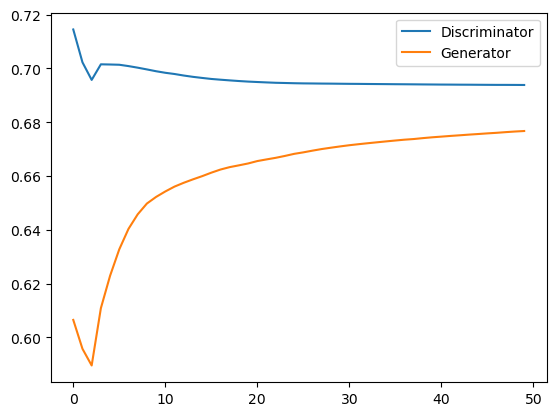

In [12]:
plt.plot(loss_d, label='Discriminator')
plt.plot(loss_g, label='Generator')
plt.legend()
plt.show()

#### 8. Discriminator Evaluation

The `model.eval()` method is called on both the Discriminator and Generator models.
This sets the models to evaluation mode, disabling behavior like dropout and batch normalization updates that are only needed during training.

We iterate the test set and compute:

*   `real_acc` computes the accuracy of the Discriminator in classifying real images by dividing the correct real classifications by the total number of real images.
*   `generated_acc` computes the accuracy of the Discriminator in classifying generated images in the same way.
*   `overall_acc` computes the overall accuracy by combining the correct classifications of both real and generated images.

In [13]:
# Set to evaluation mode
discriminator.eval()
generator.eval()

real_correct = 0
generated_correct = 0
total_size = 0

# Save all probs for visualization later
all_probabilities_real = []
all_probabilities_generated = []

with torch.no_grad():
    for real_images, _ in test_loader:
        batch_size = real_images.size(0)
        total_size += batch_size

        # Evaluate on real images, apply sigmoid to convert logit as probability
        real_logits = discriminator(real_images.to(device))
        real_prob = torch.sigmoid(real_logits.cpu())
        # Count correct predictions;
        real_correct += (real_prob > 0.5).sum().item()
        # Store logits for real samples
        all_probabilities_real.append(real_prob)

        # Evaluate on generated images
        # Generate noise
        z = torch.randn(batch_size, 100,1,1)
        # Generate images
        generated_images = generator(z.to(device))

        generated_logits = discriminator(generated_images)
        generated_probe = torch.sigmoid(generated_logits.cpu())
        # Count correct predictions
        generated_correct += (generated_probe < 0.5).sum().item()
        # Store logits for real samples
        all_probabilities_generated.append(generated_probe)

# Compute accuracy
real_acc = real_correct / total_size * 100
generated_acc = generated_correct / total_size * 100
overall_acc = (real_acc + generated_acc) / 2

print(f"Discriminator Evaluation:")
print(f"  - Accuracy on Real Images: {real_acc:.2f}%")
print(f"  - Accuracy on Generated Images: {generated_acc:.2f}%")
print(f"  - Overall Accuracy: {overall_acc:.2f}%")

Discriminator Evaluation:
  - Accuracy on Real Images: 88.81%
  - Accuracy on Generated Images: 8.16%
  - Overall Accuracy: 48.48%


We also plot the probability distributions for both real and generated samples.

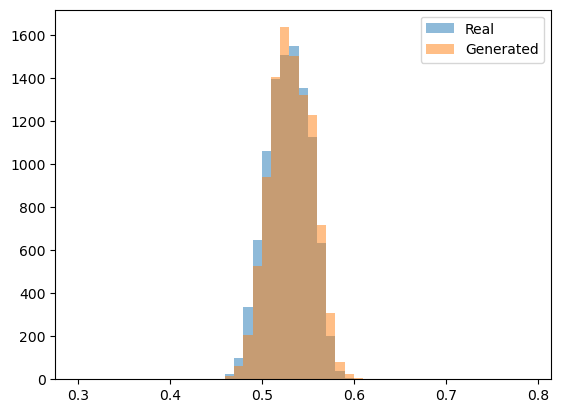

In [14]:
all_real = torch.cat(all_probabilities_real)
all_generated = torch.cat(all_probabilities_generated)

bins = torch.arange(0.3,0.8,0.01)
plt.hist(all_real.squeeze().numpy(), bins=bins, label='Real', alpha=0.5)
plt.hist(all_generated.squeeze().numpy(), bins=bins, label='Generated', alpha=0.5)
plt.legend()
plt.show()

#### 9. Visualizing Generator Output

We visualize:

1. How the trained Generator perform on random noise.
2. How the generated images from fixed noise evolve during training.

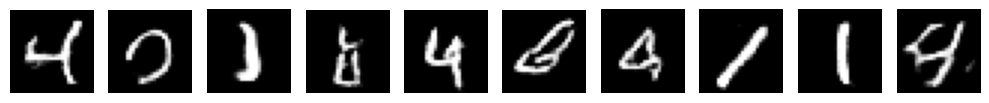

In [15]:
z = torch.randn(10, 100, 1, 1, device=device)
generated_images = generator(z.to(device))
show_images(generated_images)

In [16]:
def show_generated_images(epoch):
    """
    This function is used to display the images generated by the **Generator** during training.
    It takes the epoch number as input, loads the corresponding generated images,
    rescales them to the proper range,
    and then displays the first 30 images from the batch.
    """
    # load saved images
    epoch_data = fixed_samples[epoch-1]
    # re-shape to (batch_size, channel, height, width)
    batch_size, channel, height, width = len(epoch_data), 1, 28, 28
    image_batch = epoch_data.view(batch_size, channel, height, width)
    show_images(image_batch[:30])


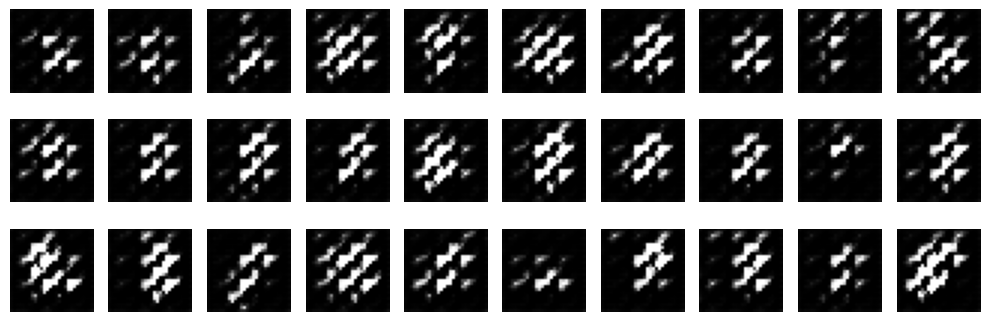

In [17]:
show_generated_images(epoch=1)

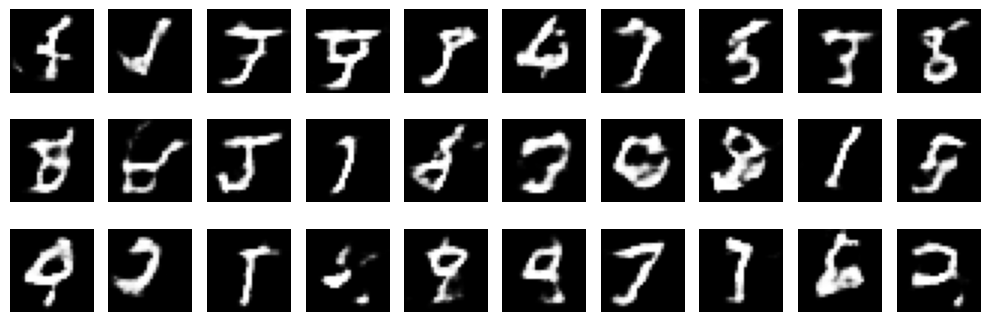

In [18]:
show_generated_images(epoch=10)

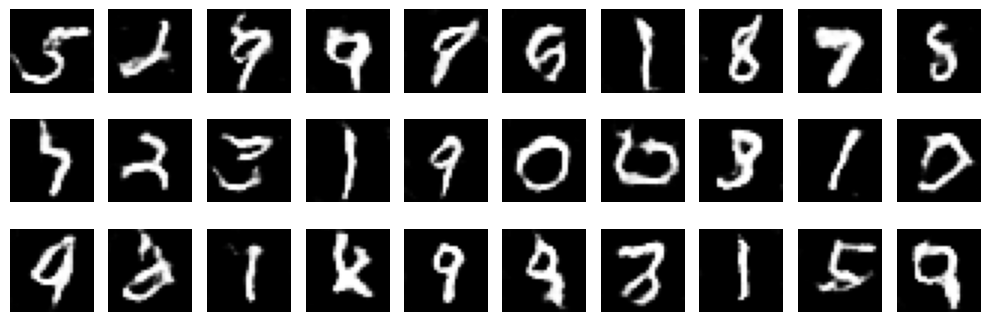

In [19]:
show_generated_images(epoch=23)

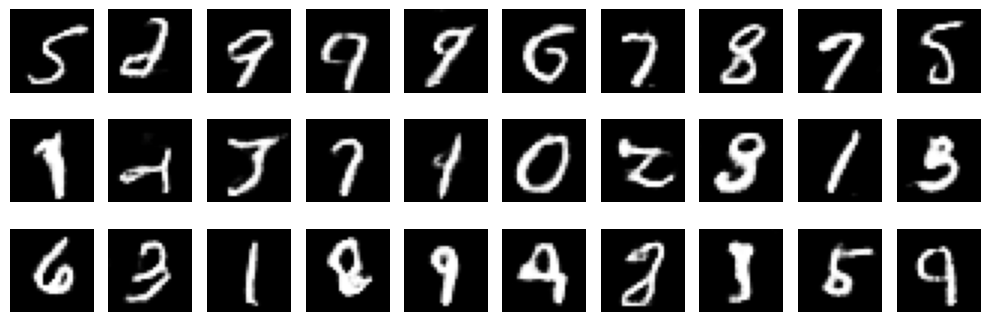

In [20]:
show_generated_images(epoch=50)